In [58]:
from google.colab import files
uploaded = files.upload()

Saving car1.zip to car1 (6).zip
Saving car2.zip to car2 (6).zip
Saving car3.zip to car3 (6).zip


In [59]:
import zipfile
import os

os.makedirs('dataset/car1', exist_ok=True)
os.makedirs('dataset/car2', exist_ok=True)
os.makedirs('dataset/car3', exist_ok=True)

with zipfile.ZipFile('car1.zip', 'r') as z:
    z.extractall('dataset/car1')

with zipfile.ZipFile('car2.zip', 'r') as z:
    z.extractall('dataset/car2')

with zipfile.ZipFile('car3.zip', 'r') as z:
    z.extractall('dataset/car3')

for car in ['car1', 'car2', 'car3']:
    print(f"{car}: {len(os.listdir(f'dataset/{car}'))} images")

car1: 21 images
car2: 22 images
car3: 20 images


In [60]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from PIL import Image
from sklearn.model_selection import train_test_split

dataset_path = 'dataset'
class_names = ['car1', 'car2', 'car3']



In [61]:
X = [] #images
y = [] #labels

for label, class_name in enumerate(class_names):
    class_folder = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        img = Image.open(img_path).convert('RGB')
        img = img.resize((32, 32))
        img_array = np.array(img)
        X.append(img_array)
        y.append(label)

X = np.array(X)
y = np.array(y)

In [62]:
X = X/255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')

])

In [64]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = cnn.fit(X_train, y_train, epochs=50, batch_size = 8, validation_data=(X_test, y_test))

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.3000 - loss: 1.1412 - val_accuracy: 0.2308 - val_loss: 1.1491
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3800 - loss: 1.0439 - val_accuracy: 0.3077 - val_loss: 1.1333
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4600 - loss: 1.0182 - val_accuracy: 0.3077 - val_loss: 1.1513
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5200 - loss: 0.9315 - val_accuracy: 0.4615 - val_loss: 1.0618
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6800 - loss: 0.7943 - val_accuracy: 0.3846 - val_loss: 1.0321
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6800 - loss: 0.7436 - val_accuracy: 0.3846 - val_loss: 1.0614
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7200 - loss: 0.6623 - val_accuracy: 0.4615 - val_loss: 0.9656
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7400 - loss: 0.5649 - val_accuracy: 0.4615 - val_loss: 1.0107


In [65]:
from google.colab import files
from PIL import Image
import numpy as np

class_names = ['Opel Astra', 'Ford Escort', 'Ford F350']

print("Upload an image to identify:")
pred_upload = files.upload()

pred_filename = list(pred_upload.keys())[0]
pred_img = Image.open(pred_filename).convert('RGB')
pred_img = pred_img.resize((32, 32))
pred_array = np.array(pred_img) / 255.0
pred_array = pred_array.reshape(1, 32, 32, 3)

prediction = cnn.predict(pred_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"\nCar: {predicted_class} (Confidence: {confidence:.2f}%)")

Upload an image to identify:


Saving car1.png to car1.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

Car: Ford F350 (Confidence: 96.51%)


(0.0, 1.0)

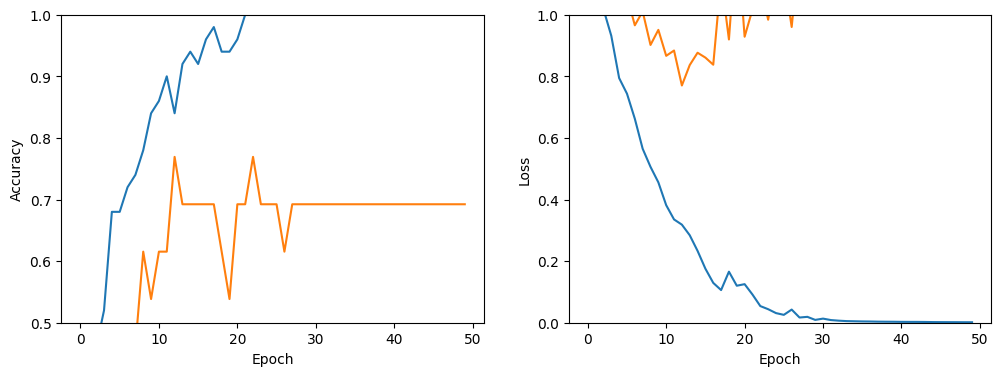

In [66]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])